In [44]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [45]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [46]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,white_share,non_white_share
0,BALDWIN,207643,122542,0.5902,0.0634,253507.0,10.0,8.268600,32.797637,0.922164,0.077836
1,BARBOUR,17666,9919,0.5615,0.0598,24585.0,25.5,22.186295,11.464715,0.603878,0.396122
2,BULLOCK,7181,4144,0.5771,0.0980,9897.0,33.6,25.955544,8.999729,0.267722,0.732278
3,BUTLER,14530,8530,0.5871,0.0544,18382.0,23.6,12.405044,13.764813,0.618713,0.381287
4,CHOCTAW,10767,6692,0.6215,0.0675,12252.0,24.8,15.781285,13.914203,0.629044,0.370956


In [47]:
candidate_features = [
    "turnout_rate",
    "poverty_rate",
    "pct_less_hs",
    "non_white_share"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,turnout_rate,poverty_rate,pct_less_hs,non_white_share
0,0.5902,10.0,8.268600,0.077836
1,0.5615,25.5,22.186295,0.396122
2,0.5771,33.6,25.955544,0.732278
3,0.5871,23.6,12.405044,0.381287
4,0.6215,24.8,15.781285,0.370956


In [48]:
pca_df.describe()

,turnout_rate,poverty_rate,pct_less_hs,non_white_share
count,25.000000,24.000000,24.000000,25.000000
mean,0.575536,24.416667,15.467159,0.475974
std,0.047023,6.375747,4.094101,0.201852
min,0.446800,10.000000,8.268600,0.077836
25%,0.551600,19.075000,12.414252,0.348480
50%,0.588500,23.700000,15.256294,0.405595
75%,0.615700,29.800000,17.557432,0.669784
max,0.626500,33.800000,25.955544,0.793572


In [ ]:
# turnout: lower turnout = higher risk
pca_df["turnout_rate"] = 1 - pca_df["turnout_rate"]

# poverty: higher poverty = higher risk
if pca_df["poverty_rate"].max() > 1:
    pca_df["poverty_rate"] = pca_df["poverty_rate"] / 100

# education: higher % less than HS = higher risk
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100

pca_df.head()

,turnout_rate,poverty_rate,pct_less_hs,non_white_share
0,0.4098,0.100,0.082686,0.077836
1,0.4385,0.255,0.221863,0.396122
2,0.4229,0.336,0.259555,0.732278
3,0.4129,0.236,0.124050,0.381287
4,0.3785,0.248,0.157813,0.370956


In [50]:
pca_df.isna().sum()

turnout_rate       0
poverty_rate       1
pct_less_hs        1
non_white_share    0
dtype: int64

In [51]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,turnout_rate,poverty_rate,pct_less_hs,non_white_share
0,0.4098,0.100,0.082686,0.077836
1,0.4385,0.255,0.221863,0.396122
2,0.4229,0.336,0.259555,0.732278
3,0.4129,0.236,0.124050,0.381287
4,0.3785,0.248,0.157813,0.370956


In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [53]:
corr = X_imputed.corr()
corr

,turnout_rate,poverty_rate,pct_less_hs,non_white_share
turnout_rate,1.000000,-0.011891,-0.120380,0.194716
poverty_rate,-0.011891,1.000000,0.554505,0.803671
pct_less_hs,-0.120380,0.554505,1.000000,0.399344
non_white_share,0.194716,0.803671,0.399344,1.000000


In [54]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [55]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.547614,0.547614
1,PC2,0.273646,0.821260
2,PC3,0.139048,0.960308
3,PC4,0.039692,1.000000


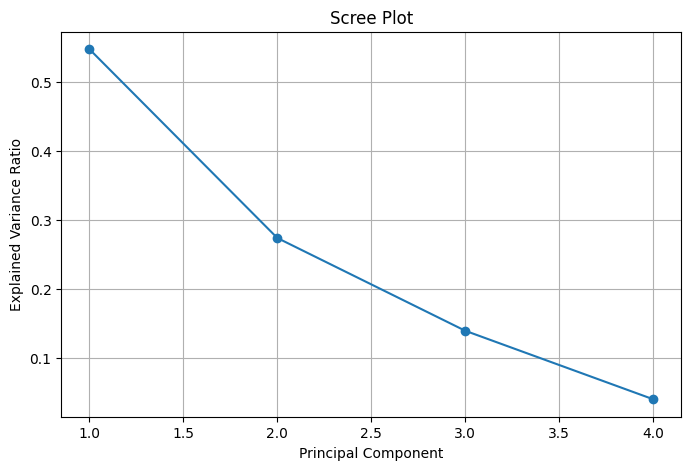

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

In [57]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4
turnout_rate,0.041897,0.913090,0.380191,0.141305
poverty_rate,0.632048,-0.029277,-0.269197,0.726079
pct_less_hs,0.490834,-0.329984,0.792906,-0.146601
non_white_share,0.598198,0.237742,-0.392794,-0.656773


In [58]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-3.602884
1,BARBOUR,0.726983
2,BULLOCK,3.037597
3,BUTLER,-0.759998
4,CHOCTAW,-0.276557


In [59]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,0.000000
1,BARBOUR,65.204115
2,BULLOCK,100.000000
3,BUTLER,42.811445
4,CHOCTAW,50.091652


In [60]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
2,BULLOCK,100.000000
23,WILCOX,87.709662
18,PERRY,83.895743
10,GREENE,83.212023
13,MACON,77.395164
12,LOWNDES,74.215497
21,SUMTER,72.980773
8,DALLAS,69.890277
1,BARBOUR,65.204115
11,HALE,59.110090


In [61]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)